In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import os
import h5py as h5
import random
from scipy.stats import zscore
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
import networkx as nx
import pandas as pd
import copy

In [2]:
def change_font(font_size = 10, font_choice = False):
    '''
    Custom function for changing the font size in a plt plot, aesthetic purposes
    '''
    font = {'family' : 'serif',
            'weight' : 'normal', #bold
            'size'   : font_size}
    
    mpl.rc('font', **font)

In [3]:
def custom_z_score(data, baseline_window, bin_window):
    '''
    Custom function that does z-score based on control condition, and bins that data, 
    to then find average mean, standard deviation values based on condition. Then when 
    z-score rest of data, it is relative to the baseline condition.

    Inputs: 
        data: numpy 2D, shape of (neurons, data)
        baseline_window: list, first 0th index inclusive to second 0th index exclusive
        bin_window: tuple int, how long (time points) of a bin to average across the baseline_window
    '''

    n_bins = int((baseline_window[1] - baseline_window[0]) / bin_window)
    z_data = np.zeros((data.shape[0], data.shape[1]))
    
    for roiID in range(data.shape[0]):
        mean_baselines = np.zeros((n_bins))
        standard_deviation_baselines = np.zeros((n_bins))
        roi_data = data[roiID]
        
        for binID in range(n_bins):
            window0 = binID * bin_window
            mean_bin = np.mean(roi_data[window0:window0+bin_window])
            standard_deviation_bin = np.std(roi_data[window0:window0+bin_window])
            mean_baselines[binID] = mean_bin
            standard_deviation_baselines[binID] = standard_deviation_bin
        
        avg_mean_baseline = np.mean(mean_baselines)
        avg_standard_deviation_baseline = np.mean(standard_deviation_baselines)
        z_data[roiID] = (data[roiID] - avg_mean_baseline) / avg_standard_deviation_baseline
        
    return z_data

In [4]:
output_folder_path = '/Volumes/Elements/cmpk2/20250326/fish2/output_stepC/'
cells_fname = os.path.join(output_folder_path, 'cells0_clean.hdf5')
volume_fname = os.path.join(output_folder_path, 'volume0.hdf5')

In [5]:
with h5.File(cells_fname) as cell_f:
    cell_timeseries = cell_f['cell_timeseries'][...]
    cell_timeseries_raw = cell_f['cell_timeseries_raw'][()]
    cell_x, cell_y, cell_z = cell_f['cell_x'][()], cell_f['cell_y'][()], cell_f['cell_z'][()]
    n_cells = cell_f['n'][...]
    background = cell_f['background'][...]
    print(cell_f.keys())

with h5.File(volume_fname) as volume_f: 
    volume_mean = volume_f['volume_mean'][...]

<KeysViewHDF5 ['background', 'cell_baseline', 'cell_block_id', 'cell_timeseries', 'cell_timeseries_raw', 'cell_weights', 'cell_x', 'cell_y', 'cell_z', 'n', 't', 'volume_id', 'volume_weight', 'x', 'y', 'z']>


In [6]:
baseline_window = [0, 1800]
bin_window = 120

data_minus_background = cell_timeseries_raw - background

z_data = custom_z_score(data_minus_background, baseline_window, bin_window)

Load the relevant data sets

In [7]:
elements_dir = '/Volumes/Elements/cmpk2/20250326/fish2/brain'

non_assigned_data_fname = os.path.join(elements_dir, 'non_assigned_fish2.csv')
non_assigned_unique_fname = os.path.join(elements_dir, 'non_assigned_unique_fish2.npy')

non_assigned_data = pd.read_csv(non_assigned_data_fname)
non_assigned_unique =np.load(non_assigned_unique_fname)


assigned_data_fname = os.path.join(elements_dir, 'assigned_fish2.csv')
assigned_unique_fname = os.path.join(elements_dir, 'assigned_unique_fish2.npy')

assigned_data = pd.read_csv(assigned_data_fname)
assigned_unique = np.load(assigned_unique_fname)

In [8]:
assigned_data['region'].unique()

<StringArray>
[                                               'nucleus_isthmi.tif',
                   'superior_ventral_medulla_oblongata_(entire).tif',
                                             'lateral_tegmentum.tif',
                             'superior_dorsal_medulla_oblongata.tif',
                                                        'tectum.tif',
                                                    'cerebellum.tif',
               'intermediate_ventral_medulla_oblongata_(entire).tif',
                                               'locus_coeruleus.tif',
                         'intermediate_dorsal_medulla_oblongata.tif',
                                'medial_octavolateralis_nucleus.tif',
                                     'peripheral_nervous_system.tif',
                                            'vagal_sensory_lobe.tif',
                                          'torus_semicircularis.tif',
                                                     'pretectum.tif',
      

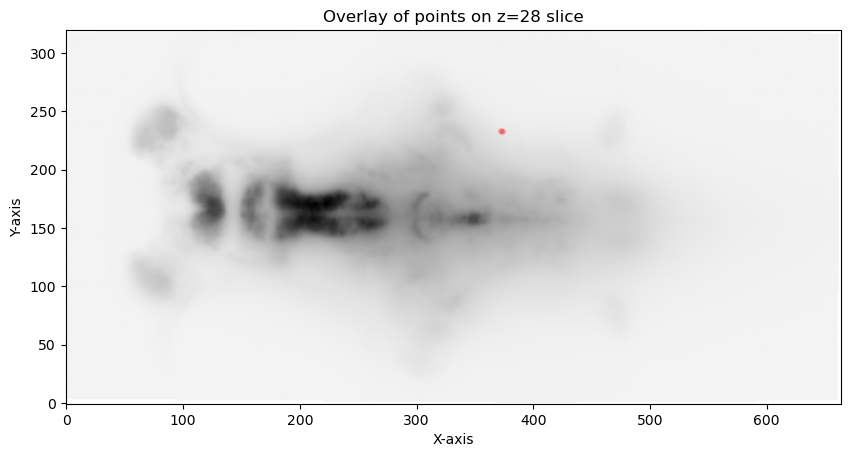

In [9]:
example_region = 'cerebellum.tif'
example_plane = 15

superior_raphe_entries = assigned_data[assigned_data['region'] == example_region]
# Select points at z=10
points_z10 = superior_raphe_entries[superior_raphe_entries['z'] == example_plane]

# Plot the background image slice
plt.figure(figsize=(10, 8))
plt.imshow(volume_mean[example_plane, :, :].T, cmap='binary', origin='lower')

# Overlay points (x, y)
plt.scatter(points_z10['y'], points_z10['x'], c='r', s=10, alpha=0.1)

# Add labels and title
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Overlay of points on z=28 slice')
plt.show()


In [10]:
superior_raphe_entries

,Unnamed: 0,cell_id,x,y,z,region
18564,18733,849,239,353,25,cerebellum.tif
18565,18734,849,239,354,25,cerebellum.tif
18566,18735,849,239,355,25,cerebellum.tif
18567,18736,849,240,352,25,cerebellum.tif
18568,18737,849,240,353,25,cerebellum.tif
...,...,...,...,...,...,...
1853583,3691576,258617,172,385,46,cerebellum.tif
1853584,3691577,258617,173,382,45,cerebellum.tif
1853585,3691578,258617,173,383,45,cerebellum.tif
1853586,3691579,258617,173,384,45,cerebellum.tif


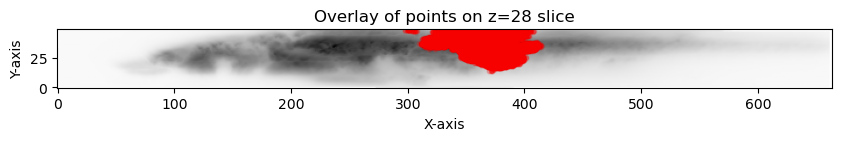

In [11]:
superior_raphe_entries = assigned_data[assigned_data['region'] == example_region]
# Select points at z=10
# points_z10 = superior_raphe_entries[superior_raphe_entries['z'] == example_plane]

# Plot the background image slice
plt.figure(figsize=(10, 20))
plt.imshow(np.max(volume_mean, axis=2).T.T, cmap='binary', origin='lower')

# Overlay points (x, y)
plt.scatter(superior_raphe_entries['y'], superior_raphe_entries['z'], c='r', s=10, alpha=0.1)

# Add labels and title
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Overlay of points on z=28 slice')
plt.show()

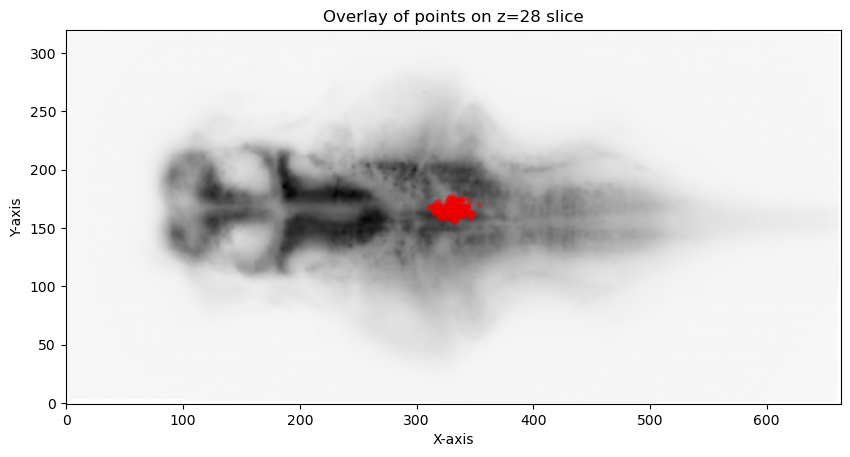

In [12]:
example_region = 'superior_raphe.tif'
example_plane = 28

superior_raphe_entries = assigned_data[assigned_data['region'] == example_region]
# Select points at z=10
points_z10 = superior_raphe_entries[superior_raphe_entries['z'] == example_plane]

# Plot the background image slice
plt.figure(figsize=(10, 8))
plt.imshow(volume_mean[example_plane, :, :].T, cmap='binary', origin='lower')

# Overlay points (x, y)
plt.scatter(points_z10['y'], points_z10['x'], c='r', s=10, alpha=0.1)

# Add labels and title
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Overlay of points on z=28 slice')
plt.show()


exploring ...

In [13]:
assigned_data

,Unnamed: 0,cell_id,x,y,z,region
0,12,1,232,313,16,nucleus_isthmi.tif
1,13,1,232,313,16,superior_ventral_medulla_oblongata_(entire).tif
2,14,1,232,313,17,nucleus_isthmi.tif
3,15,1,232,313,17,superior_ventral_medulla_oblongata_(entire).tif
4,16,1,232,314,17,nucleus_isthmi.tif
...,...,...,...,...,...,...
1912678,3841625,270384,179,590,35,vagus_motor_nucleus.tif
1912679,3841626,270384,179,590,36,vagus_motor_nucleus.tif
1912680,3841627,270384,180,589,35,vagus_motor_nucleus.tif
1912681,3841628,270384,180,589,36,vagus_motor_nucleus.tif


In [14]:
example_plane = 28 
asssigned_data_example_plane = assigned_data[assigned_data['z'] == example_plane]
example_plane_regions = asssigned_data_example_plane['region'].unique()
print('{0} regions in the plane: {1}'.format(len(example_plane_regions), example_plane))
for regionID in example_plane_regions:
    print(regionID)

25 regions in the plane: 28
tectum.tif
nucleus_isthmi.tif
superior_ventral_medulla_oblongata_(entire).tif
cerebellum.tif
lateral_tegmentum.tif
superior_dorsal_medulla_oblongata.tif
medial_octavolateralis_nucleus.tif
intermediate_ventral_medulla_oblongata_(entire).tif
intermediate_dorsal_medulla_oblongata.tif
peripheral_nervous_system.tif
pretectum.tif
torus_semicircularis.tif
area_postrema.tif
olfactory_bulb.tif
eminentia_thalami.tif
prethalamus_(ventral_thalamus).tif
medial_tegmentum_(entire).tif
intermediate_hypothalamus_(entire).tif
vagal_sensory_lobe.tif
preoptic_region.tif
posterior_tuberculum_(basal_part_of_prethalamus_and_thalamus).tif
locus_coeruleus.tif
vagus_motor_nucleus.tif
superior_raphe.tif
inferior_raphe.tif


In [15]:
all_region_names = assigned_data['region'].unique()

In [16]:
# randomly sample the data for two ROIs
colorz_dict = {}

cmap_name = 'tab20b'
cmap = mpl.colormaps.get_cmap(cmap_name)
norm = mpl.colors.Normalize(vmin=0, vmax=len(all_region_names))

for region_idx, regionID in enumerate(all_region_names):
    rgba = cmap(norm(region_idx))
    colorz_dict[regionID] = rgba

### NOTE TO READER: 

The cells below are commented out for reducing the file size. 

tectum.tif
nucleus_isthmi.tif
superior_ventral_medulla_oblongata_(entire).tif
cerebellum.tif
lateral_tegmentum.tif
superior_dorsal_medulla_oblongata.tif
medial_octavolateralis_nucleus.tif
intermediate_ventral_medulla_oblongata_(entire).tif
intermediate_dorsal_medulla_oblongata.tif
peripheral_nervous_system.tif
pretectum.tif
torus_semicircularis.tif
area_postrema.tif
olfactory_bulb.tif
eminentia_thalami.tif
prethalamus_(ventral_thalamus).tif
medial_tegmentum_(entire).tif
intermediate_hypothalamus_(entire).tif
vagal_sensory_lobe.tif
preoptic_region.tif
posterior_tuberculum_(basal_part_of_prethalamus_and_thalamus).tif
locus_coeruleus.tif
vagus_motor_nucleus.tif
superior_raphe.tif
inferior_raphe.tif


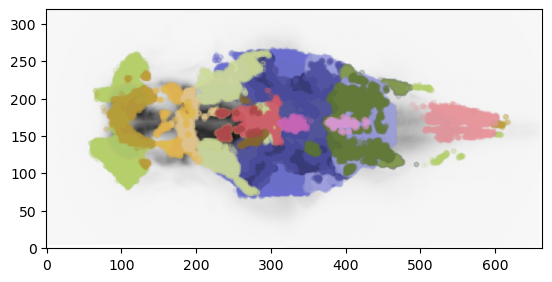

In [17]:
plt.imshow(volume_mean[example_plane, :, :].T, cmap='binary', origin='lower')

for regionID in example_plane_regions:
    print(regionID)
    region_data = asssigned_data_example_plane[asssigned_data_example_plane['region'] == regionID]
    plt.scatter(region_data['y'], region_data['x'], color=colorz_dict[regionID], s=10, alpha=0.1)
    # break


In [18]:
'''
plt.imshow(np.max(volume_mean, axis=2), cmap='gist_grey')

for regionID in example_plane_regions:
    region_data = asssigned_data_example_plane[asssigned_data_example_plane['region'] == regionID]
    plt.scatter(region_data['y'], region_data['z'], color=colorz_dict[regionID], s=10, alpha=0.1)
'''


"\nplt.imshow(np.max(volume_mean, axis=2), cmap='gist_grey')\n\nfor regionID in example_plane_regions:\n    region_data = asssigned_data_example_plane[asssigned_data_example_plane['region'] == regionID]\n    plt.scatter(region_data['y'], region_data['z'], color=colorz_dict[regionID], s=10, alpha=0.1)\n"

In [19]:
'''
change_font(font_size=20)

fig, ax = plt.subplots(figsize=(2, 2))
# custom_labelz = ['average activity', 'flicks', 'auditory stimuli']
custom_labelz = ['average activity', 'flicks']

# Create dummy handles for your legend entries
handles = [
    mpl.patches.Patch(color=colorz_dict[regionID], label=regionID, linestyle='solid')
    for regionID in all_region_names
]

ax.legend(handles=handles, loc='center')
ax.axis('off')  # hide the empty axes

# plt.tight_layout()
plt.show()
'''

"\nchange_font(font_size=20)\n\nfig, ax = plt.subplots(figsize=(2, 2))\n# custom_labelz = ['average activity', 'flicks', 'auditory stimuli']\ncustom_labelz = ['average activity', 'flicks']\n\n# Create dummy handles for your legend entries\nhandles = [\n    mpl.patches.Patch(color=colorz_dict[regionID], label=regionID, linestyle='solid')\n    for regionID in all_region_names\n]\n\nax.legend(handles=handles, loc='center')\nax.axis('off')  # hide the empty axes\n\n# plt.tight_layout()\nplt.show()\n"

Trying to plot all regions across all slices 

In [20]:
'''
# plot spatial distribution of sound-responsive neurons

save_path = os.path.join(elements_dir, 'all_regions.png')
# --- Plot function ---

num_planes = 50
n_rows = 5
n_cols = 10
dot_size=4
alpha=.1
figsize=(30, 15)
img_height = volume_mean[0, :, :].T.shape[0]

fig, axs = plt.subplots(n_rows, n_cols, figsize=figsize)
axs = axs.flatten()

for plane in range(num_planes):
    ax = axs[plane]
    ax.imshow(volume_mean[plane, :, :].T, cmap='gray')
    asssigned_data_example_plane = assigned_data[assigned_data['z'] == plane]
    example_plane_regions = asssigned_data_example_plane['region'].unique()
    for regionID in example_plane_regions:
        region_data = asssigned_data_example_plane[asssigned_data_example_plane['region'] == regionID]
        ax.scatter(region_data['y'], region_data['x'], color=colorz_dict[regionID], s=10, alpha=0.01)

    ax.axis('off')

# Turn off unused axes if fewer than n_rows*n_cols
for remaining_ax in axs[num_planes:]:
    remaining_ax.axis('off')

plt.tight_layout(); plt.subplots_adjust(hspace=0.01, wspace=0.01)

if save_path:
    # os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=500, bbox_inches='tight')

plt.show()


# # --- Example usage ---
# # robustly_responsive_indices comes from your split-half script
# plot_robustly_responsive_neurons_spatial(
#     cells_x=cells_x,
#     cells_y=cells_y,
#     cells_z=cells_z,
#     robustly_responsive_indices=robustly_responsive_indices,
#     volume_mean_rotated=volume_mean,
#     num_planes=50,
#     save_path=os.path.join(fish_dir, 'plots/robustly_responsive_neurons_first8.png'),
#     dot_size=4
# )
'''

"\n# plot spatial distribution of sound-responsive neurons\n\nsave_path = os.path.join(elements_dir, 'all_regions.png')\n# --- Plot function ---\n\nnum_planes = 50\nn_rows = 5\nn_cols = 10\ndot_size=4\nalpha=.1\nfigsize=(30, 15)\nimg_height = volume_mean[0, :, :].T.shape[0]\n\nfig, axs = plt.subplots(n_rows, n_cols, figsize=figsize)\naxs = axs.flatten()\n\nfor plane in range(num_planes):\n    ax = axs[plane]\n    ax.imshow(volume_mean[plane, :, :].T, cmap='gray')\n    asssigned_data_example_plane = assigned_data[assigned_data['z'] == plane]\n    example_plane_regions = asssigned_data_example_plane['region'].unique()\n    for regionID in example_plane_regions:\n        region_data = asssigned_data_example_plane[asssigned_data_example_plane['region'] == regionID]\n        ax.scatter(region_data['y'], region_data['x'], color=colorz_dict[regionID], s=10, alpha=0.01)\n\n    ax.axis('off')\n\n# Turn off unused axes if fewer than n_rows*n_cols\nfor remaining_ax in axs[num_planes:]:\n    remai

In [21]:
'''
# plot spatial distribution of sound-responsive neurons
region_label = 'torus_semicircularis.tif'


save_path = os.path.join(elements_dir, 'all_regions.png')
# --- Plot function ---

num_planes = 50
n_rows = 5
n_cols = 10
dot_size=4
alpha=.1
figsize=(30, 15)
img_height = volume_mean[0, :, :].T.shape[0]

fig, axs = plt.subplots(n_rows, n_cols, figsize=figsize)
axs = axs.flatten()

for plane in range(num_planes):
    ax = axs[plane]
    ax.imshow(volume_mean[plane, :, :], cmap='gray')
    asssigned_data_example_plane = assigned_data[assigned_data['z'] == plane]
    # example_plane_regions = asssigned_data_example_plane['region'].unique()
    
    superior_raphe_entries = asssigned_data_example_plane[asssigned_data_example_plane['region'] == region_label]
    ax.scatter(superior_raphe_entries['x'][::-1], superior_raphe_entries['y'][::-1], c='cyan', s=1, alpha=0.01)

    ax.axis('off')

# Turn off unused axes if fewer than n_rows*n_cols
for remaining_ax in axs[num_planes:]:
    remaining_ax.axis('off')

plt.tight_layout(); plt.subplots_adjust(hspace=0.01, wspace=0.01)

if save_path:
    # os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=1000, bbox_inches='tight')

plt.show()


# # --- Example usage ---
# # robustly_responsive_indices comes from your split-half script
# plot_robustly_responsive_neurons_spatial(
#     cells_x=cells_x,
#     cells_y=cells_y,
#     cells_z=cells_z,
#     robustly_responsive_indices=robustly_responsive_indices,
#     volume_mean_rotated=volume_mean,
#     num_planes=50,
#     save_path=os.path.join(fish_dir, 'plots/robustly_responsive_neurons_first8.png'),
#     dot_size=4
# )
'''

"\n# plot spatial distribution of sound-responsive neurons\nregion_label = 'torus_semicircularis.tif'\n\n\nsave_path = os.path.join(elements_dir, 'all_regions.png')\n# --- Plot function ---\n\nnum_planes = 50\nn_rows = 5\nn_cols = 10\ndot_size=4\nalpha=.1\nfigsize=(30, 15)\nimg_height = volume_mean[0, :, :].T.shape[0]\n\nfig, axs = plt.subplots(n_rows, n_cols, figsize=figsize)\naxs = axs.flatten()\n\nfor plane in range(num_planes):\n    ax = axs[plane]\n    ax.imshow(volume_mean[plane, :, :], cmap='gray')\n    asssigned_data_example_plane = assigned_data[assigned_data['z'] == plane]\n    # example_plane_regions = asssigned_data_example_plane['region'].unique()\n\n    superior_raphe_entries = asssigned_data_example_plane[asssigned_data_example_plane['region'] == region_label]\n    ax.scatter(superior_raphe_entries['x'][::-1], superior_raphe_entries['y'][::-1], c='cyan', s=1, alpha=0.01)\n\n    ax.axis('off')\n\n# Turn off unused axes if fewer than n_rows*n_cols\nfor remaining_ax in axs[

Creating mask so that can use as template for fish brain and then plot points on top of ..

In [22]:
'''
slice_idx_ex = 17
ex_assigned_data = copy.deepcopy(assigned_data)
my_selection = ex_assigned_data[(ex_assigned_data['region'] == 'nucleus_isthmi.tif') & (ex_assigned_data['z'] == slice_idx_ex)]
my_selection_dropped = ex_assigned_data.drop((ex_assigned_data['region'] == 'nucleus_isthmi.tif') & (ex_assigned_data['z'] != slice_idx_ex))
my_selection_dropped[my_selection_dropped['region'] == 'nucleus_isthmi.tif']
'''

"\nslice_idx_ex = 17\nex_assigned_data = copy.deepcopy(assigned_data)\nmy_selection = ex_assigned_data[(ex_assigned_data['region'] == 'nucleus_isthmi.tif') & (ex_assigned_data['z'] == slice_idx_ex)]\nmy_selection_dropped = ex_assigned_data.drop((ex_assigned_data['region'] == 'nucleus_isthmi.tif') & (ex_assigned_data['z'] != slice_idx_ex))\nmy_selection_dropped[my_selection_dropped['region'] == 'nucleus_isthmi.tif']\n"

In [23]:
'''
region_label = 'preoptic_region.tif'
a = assigned_data[assigned_data['region']==region_label]['x']
a.to_numpy()
'''

array([199, 199, 199, ..., 173, 173, 173], shape=(72012,))

In [24]:
'''
plane=15
asssigned_data_example_plane = assigned_data[assigned_data['z'] == plane]
asssigned_data_example_plane
'''

,Unnamed: 0,cell_id,x,y,z,region
126,138,7,233,319,15,nucleus_isthmi.tif
127,139,7,233,319,15,superior_ventral_medulla_oblongata_(entire).tif
128,140,7,233,320,15,nucleus_isthmi.tif
129,141,7,233,320,15,superior_ventral_medulla_oblongata_(entire).tif
132,144,7,234,318,15,nucleus_isthmi.tif
...,...,...,...,...,...,...
1895351,3809478,267768,178,516,15,inferior_olive.tif
1895386,3809837,267795,180,512,15,inferior_olive.tif
1895388,3809839,267795,180,513,15,inferior_olive.tif
1895394,3809845,267795,181,513,15,inferior_olive.tif


In [25]:
'''
num_planes = 50

mask_template = np.zeros((num_planes, volume_mean.shape[1],volume_mean.shape[2]))

for plane in range(num_planes):
    asssigned_data_example_plane = assigned_data[assigned_data['z'] == plane]

    example_plane_regions = asssigned_data_example_plane['region'].unique()
    
    for regionID in example_plane_regions:
        region_data = asssigned_data_example_plane[asssigned_data_example_plane['region'] == regionID]
        mask_template[plane,region_data['y'].to_numpy()[::-1], region_data['x'].to_numpy()[::-1] ] = 1
'''    

NameError: name 'num_planes' is not defined

In [ ]:
'''
assigned_data['region'].unique()
'''

In [ ]:
'''
mask_template.shape
'''

In [ ]:
'''
region_label = 'peripheral_nervous_system.tif'
region_label_b = 'area_postrema.tif'
superior_raphe_entries = assigned_data[assigned_data['region'] == region_label]
area_postrema_entries = assigned_data[assigned_data['region'] == region_label_b]

# Select points at z=10
# points_z10 = superior_raphe_entries[superior_raphe_entries['z'] == example_plane]

# Plot the background image slice
plt.figure(figsize=(5, 10))
change_font(font_size=10)
plt.imshow(np.mean(mask_template, axis=0), cmap='binary', vmax=2, alpha=.75)

plt.scatter(superior_raphe_entries['x'], superior_raphe_entries['y'], c='blue', s=.1, alpha=0.1)
plt.scatter(area_postrema_entries['x'], area_postrema_entries['y'], c='red', s=.1, alpha=0.1)

# Add labels and title
# plt.xlabel('X-axis')
# plt.ylabel('Y-axis')
# plt.title('Overlay of points on z=28 slice')
plt.axis('off')
plt.show()
'''

In [ ]:
'''
superior_raphe_entries['y'].to_numpy()
'''

In [ ]:
'''
superior_raphe_entries['y'].to_numpy()[::-1]
'''

In [ ]:
'''
# region_label = 'superior_raphe.tif'
# superior_raphe_entries = assigned_data[assigned_data['region'] == region_label]
# Select points at z=10
# points_z10 = superior_raphe_entries[superior_raphe_entries['z'] == example_plane]

# Plot the background image slice
change_font(font_size=6)

plt.figure(figsize=(10, 5))
# Add labels and title
# plt.xlabel('X-axis')
# plt.ylabel('Y-axis')
plt.axis('off')
plt.imshow(np.max(mask_template, axis=2)[::-1], cmap='binary', vmax=2,alpha=.75)
plt.scatter(superior_raphe_entries['y'], superior_raphe_entries['z'], c='blue', s=1, alpha=0.005)
plt.scatter(area_postrema_entries['y'].to_numpy(), area_postrema_entries['z'].to_numpy()[::-1], c='red', s=1, alpha=0.005)

plt.show()
'''

In [ ]:
'''
# superior_raphe_entries = assigned_data[assigned_data['region'] == region_label]
# Select points at z=10
# points_z10 = superior_raphe_entries[superior_raphe_entries['z'] == example_plane]

# Plot the background image slice
plt.figure(figsize=(5, 5))
change_font(font_size=10)
plt.imshow(np.max(mask_template, axis=1)[::-1], cmap='binary', vmax=2,alpha=.15)
plt.scatter(superior_raphe_entries['x'], superior_raphe_entries['z'][::-1], c='blue', s=1, alpha=0.005)

plt.scatter(area_postrema_entries['x'], area_postrema_entries['z'][::-1], c='red', s=1, alpha=0.005)

# Add labels and title
# plt.xlabel('X-axis')
# plt.ylabel('Y-axis')
# plt.title('Overlay of points on z=28 slice')
plt.axis('off')
plt.show()
'''

In [ ]:
'''
mask_with_region_template = np.zeros((num_planes, volume_mean.shape[1],volume_mean.shape[2]))

region_label = ['olfactory_bulb.tif', 'pretectum.tif', 'cerebellum.tif']
corr_region = {'olfactory_bulb.tif':0.6, 'pretectum.tif':0.8, 'cerebellum.tif':0.9}
region_idx = 0 

for plane in range(num_planes):
    ax = axs[plane]
    # ax.imshow(volume_mean[plane, :, :].T, cmap='gray')
    asssigned_data_example_plane = assigned_data[assigned_data['z'] == plane]
    
    example_plane_regions = asssigned_data_example_plane['region'].unique()
    
    for regionID in example_plane_regions:
        
        region_data = asssigned_data_example_plane[asssigned_data_example_plane['region'] == regionID]

        if regionID in region_label:
            # print(regionID, region_idx)
            mask_with_region_template[plane,region_data['y'], region_data['x'] ] = corr_region[regionID]

        else:
            mask_with_region_template[plane,region_data['y'], region_data['x'] ] = 1
'''

In [ ]:
'''
# Select points at z=10
# points_z10 = superior_raphe_entries[superior_raphe_entries['z'] == example_plane]

# Plot the background image slice
plt.figure(figsize=(5, 5))
change_font(font_size=10)
# Add labels and title
# plt.xlabel('X-axis')
# plt.ylabel('Y-axis')
plt.title('Overlay of points on z=28 slice')
plt.axis('off')
plt.imshow(np.max(mask_with_region_template, axis=0), cmap='hot', vmax=1, vmin=.5, alpha=.8)
plt.colorbar()
plt.show()
'''

In [ ]:
'''
# Select points at z=10
# points_z10 = superior_raphe_entries[superior_raphe_entries['z'] == example_plane]

# Plot the background image slice
plt.figure(figsize=(5, 5))
change_font(font_size=10)
# Add labels and title
# plt.xlabel('X-axis')
# plt.ylabel('Y-axis')
plt.title('Overlay of points on z=28 slice')
plt.axis('off')
plt.imshow(np.max(mask_with_region_template, axis=2), cmap='hot', vmax=1, vmin=.5, alpha=.8)
plt.colorbar()
plt.show()
'''

Practing 